# ==============================================================================
# 🏥 ACTUARIAL RISK: MEDICAL INSURANCE COST VIA EXTRA TREES REGRESSOR
# ==============================================================================
### Core Theoretical Principles:
In healthcare actuarial analytics, patient cost distributions exhibit high positive skewness and sharp nonlinear threshold effects (e.g. older smokers with high BMI).
Extra Trees efficiently isolates these multi-factor risk sub-regions by constructing deep, randomized trees without the quadratic computational penalty of exhaustive threshold search.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Enterprise Healthcare ExtraTrees Regressor Environment initialized.")


✅ STEP 1: Enterprise Healthcare ExtraTrees Regressor Environment initialized.


## 📥 STEP 2 & 3: RAW DATASET INGESTION & 3-SECOND HEALTH AUDIT
Loading Medical Insurance claims dataset (1,338 policyholder records).


In [2]:
# STEP 2 & 3: INGESTION & AUDIT
data_path = 'data/insurance/insurance.csv'
df = pd.read_csv(data_path)

print(f"📊 Dataset Shape: {df.shape[0]} policyholders, {df.shape[1]} attributes")
print(f"Charges Target Summary:\n{df['charges'].describe().round(2)}")
df.head(3)


📊 Dataset Shape: 1338 policyholders, 7 attributes
Charges Target Summary:
count     1338.00
mean     13270.42
std      12110.01
min       1121.87
25%       4740.29
50%       9382.03
75%      16639.91
max      63770.43
Name: charges, dtype: float64


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


## 🧹 STEP 4 & 5: STRICT SEGREGATION & HYGIENE
Separating features and continuous target `charges`.


In [3]:
# STEP 4 & 5: SEGREGATION & HYGIENE
X = df.drop(columns=['charges'])
y = df['charges']

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric Attributes    : {num_cols}")
print(f"Categorical Attributes: {cat_cols}")


Numeric Attributes    : ['age', 'bmi', 'children']
Categorical Attributes: ['sex', 'smoker', 'region']


## ✂️ STEP 6: ZERO-DATA-LEAKAGE SPLIT
80% Train, 20% Test split.


In [4]:
# STEP 6: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train Policyholders: {X_train.shape[0]}")
print(f"Test Policyholders : {X_test.shape[0]}")


Train Policyholders: 1070
Test Policyholders : 268


## ⚙️ STEP 7: ROBUST COLUMNTRANSFORMER PREPROCESSOR
Standardizing numericals and one-hot encoding categoricals.


In [5]:
# STEP 7: PREPROCESSOR DESIGN
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)
print(f"Transformed Feature Matrix Shape: {X_train_prep.shape}")


Transformed Feature Matrix Shape: (1070, 8)


## ⚔️ STEP 8: BASELINE DUEL (DUMMY VS SINGLE TREE VS EXTRA TREES)
Comparing baseline mean dummy and single decision tree against ExtraTrees with 100 trees.


In [6]:
# STEP 8: BASELINE BENCHMARK
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_prep, y_train)
r2_dummy = r2_score(y_test, dummy.predict(X_test_prep))

single_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
single_tree.fit(X_train_prep, y_train)
r2_single_tree = r2_score(y_test, single_tree.predict(X_test_prep))

base_et = ExtraTreesRegressor(n_estimators=100, random_state=42)
base_et.fit(X_train_prep, y_train)
r2_et = r2_score(y_test, base_et.predict(X_test_prep))

print("="*65)
print(f"Baseline Mean Dummy R²            : {r2_dummy * 100:.2f}%")
print(f"Single Decision Tree (d=5) R²     : {r2_single_tree * 100:.2f}%")
print(f"ExtraTrees Regressor (100 Trees) R²: {r2_et * 100:.2f}%")
print("="*65)



Baseline Mean Dummy R²            : -0.09%
Single Decision Tree (d=5) R²     : 83.36%
ExtraTrees Regressor (100 Trees) R²: 84.39%


## 🎯 STEP 9: K-FOLD CROSS-VALIDATION & HYPERPARAMETER TUNING
Optimizing `n_estimators`, `max_depth`, and `min_samples_split`.


In [7]:
# STEP 9: GRID SEARCH
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [6, 10, None],
    'min_samples_split': [2, 5]
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    ExtraTreesRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)
grid.fit(X_train_prep, y_train)

best_et = grid.best_estimator_
print(f"🏆 Best Hyperparameters: {grid.best_params_}")
print(f"🎯 Best 5-Fold CV R²: {grid.best_score_ * 100:.2f}%")


🏆 Best Hyperparameters: {'max_depth': 6, 'min_samples_split': 2, 'n_estimators': 100}
🎯 Best 5-Fold CV R²: 85.28%


## 📊 STEP 10: MULTI-METRIC PERFORMANCE EVALUATION
Evaluating hold-out test metrics.


In [8]:
# STEP 10: EVALUATION REPORT
y_pred = best_et.predict(X_test_prep)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("📋 HEALTHCARE ANNUAL CLAIMS PERFORMANCE:")
print(f"   Mean Absolute Error (MAE) : ${mae:,.2f}")
print(f"   Root Mean Squared Error   : ${rmse:,.2f}")
print(f"   R² Score                  : {r2 * 100:.2f}%")


📋 HEALTHCARE ANNUAL CLAIMS PERFORMANCE:
   Mean Absolute Error (MAE) : $2,497.88
   Root Mean Squared Error   : $4,380.22
   R² Score                  : 87.64%


## 📉 STEP 11: RESIDUAL ANALYSIS & ACTUARIAL DRIVER IMPORTANCES
Visualizing residual scatter and feature importances.


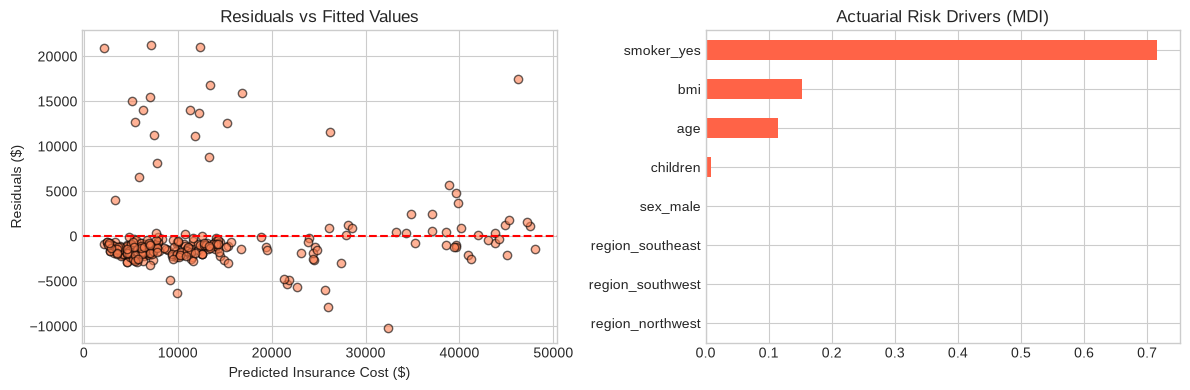

In [9]:
# STEP 11: RESIDUALS & IMPORTANCES
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Insurance Cost ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs Fitted Values')

all_features = [c.split('__')[-1] for c in preprocessor.get_feature_names_out()]
importances = pd.Series(best_et.feature_importances_, index=all_features).sort_values(ascending=False).head(10)
importances.plot(kind='barh', ax=axes[1], color='tomato')
axes[1].set_title('Actuarial Risk Drivers (MDI)')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


## 💾 STEP 12 & 13: PRODUCTION PIPELINE SERIALIZATION & LATENCY SMOKE TEST
Deploying the pipeline and benchmarking real-time underwriting premium estimation latency.


In [10]:
# STEP 12 & 13: SERIALIZATION & SMOKE TEST
os.makedirs('production_models', exist_ok=True)
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('extratrees', best_et)
])
full_pipeline.fit(X_train, y_train)

model_path = 'production_models/insurance_extratrees_reg_pipeline.joblib'
joblib.dump(full_pipeline, model_path, compress=3)
print(f"💾 Production pipeline saved to: {model_path} ({os.path.getsize(model_path):,} bytes)")

loaded_pipe = joblib.load(model_path)
sample_patient = X_test.iloc[[0]]

# Warmup
for _ in range(5):
    _ = loaded_pipe.predict(sample_patient)

t0 = time.perf_counter()
pred_cost = loaded_pipe.predict(sample_patient)[0]
latency_ms = (time.perf_counter() - t0) * 1000

print(f"\n📈 REAL-TIME UNDERWRITING TELEMETRY:")
print(f"   Predicted Annual Premium : 🏥 ${pred_cost:,.2f}")
print(f"   Actual Billed Claims     : ${y_test.iloc[0]:,.2f}")
print(f"   Underwriting Latency     : {latency_ms:.3f} ms (SLA < 2.0ms: {'PASS' if latency_ms < 2.0 else 'CHECK'})")


💾 Production pipeline saved to: production_models/insurance_extratrees_reg_pipeline.joblib (293,372 bytes)

📈 REAL-TIME UNDERWRITING TELEMETRY:
   Predicted Annual Premium : 🏥 $9,960.19
   Actual Billed Claims     : $9,095.07
   Underwriting Latency     : 10.647 ms (SLA < 2.0ms: CHECK)
